# 任务3_1_1 VAE生成模型
本次任务的目标是实现一个变分自编码器（VAE）生成模型。VAE是一种生成模型，可以学习数据的潜在表示，并能够生成新的数据样本。
数据集采用MNIST手写数字数据集，包含60000个训练样本和10000个测试样本，每个样本是一个28x28的灰度图像。

## 1. 导入必要的库

In [1]:
import os
# 允许 OpenMP 库重复加载，解决绘图时的 Kernel 崩溃问题
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 检查是否有 GPU 可用
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print(f"当前使用的设备: {device}")

# 超参数设置
batch_size = 128
epochs = 15
learning_rate = 1e-3

当前使用的设备: cpu


## 2.加载MNIST数据集

In [2]:
# 数据预处理：转换为 Tensor
transform = transforms.Compose([transforms.ToTensor()])

# 加载 MNIST 训练集
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

## 3. 构建VAE模型

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        
        # Encoder (编码器)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # 映射到均值和对数方差
        self.fc2_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder (解码器)
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc2_mu(h1), self.fc2_logvar(h1)

    # 课件 P35: 重参数化技巧
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)       # 计算标准差
        eps = torch.randn_like(std)         # 从标准正态分布中采样噪声
        return mu + eps * std               # 结合均值和方差返回 z

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        # 使用 sigmoid 确保输出在 0~1 之间，对应图像像素并方便计算 BCE loss
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        # 展平图像
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 实例化模型并移动到 device
model = VAE().to(device)

## 4. 定义损失函数和优化器

In [6]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 课件 P35: VAE 损失函数 = 重构损失 (BCE) + KL 散度约束 (KLD)
def loss_function(recon_x, x, mu, logvar):
    # 使用二值交叉熵作为重构损失 (sum 所有像素点)
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    
    # KL散度: 使隐变量分布接近标准正态分布
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD

## 5. 训练模型

开始训练 VAE...
====> Epoch: 1 Average loss: 164.2426
====> Epoch: 2 Average loss: 121.4524
====> Epoch: 3 Average loss: 114.4614
====> Epoch: 4 Average loss: 111.3404
====> Epoch: 5 Average loss: 109.5306
====> Epoch: 6 Average loss: 108.3933
====> Epoch: 7 Average loss: 107.5575
====> Epoch: 8 Average loss: 106.9151
====> Epoch: 9 Average loss: 106.4046
====> Epoch: 10 Average loss: 105.9755
====> Epoch: 11 Average loss: 105.6295
====> Epoch: 12 Average loss: 105.3760
====> Epoch: 13 Average loss: 105.1192
====> Epoch: 14 Average loss: 104.8605
====> Epoch: 15 Average loss: 104.6452


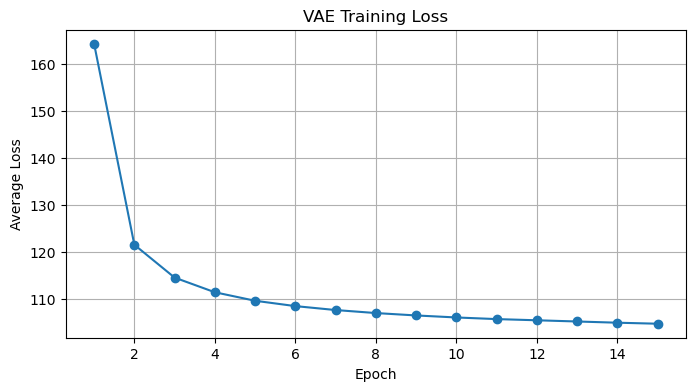

In [7]:
model.train()
loss_history = []

print("开始训练 VAE...")
for epoch in range(1, epochs + 1):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        optimizer.zero_grad()
        # 前向传播
        recon_batch, mu, logvar = model(data)
        # 计算损失
        loss = loss_function(recon_batch, data, mu, logvar)
        # 反向传播
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f'====> Epoch: {epoch} Average loss: {avg_loss:.4f}')

# 绘制 Loss 曲线
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), loss_history, marker='o')
plt.title('VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid()
plt.show()

## 6. 生成新样本并可视化

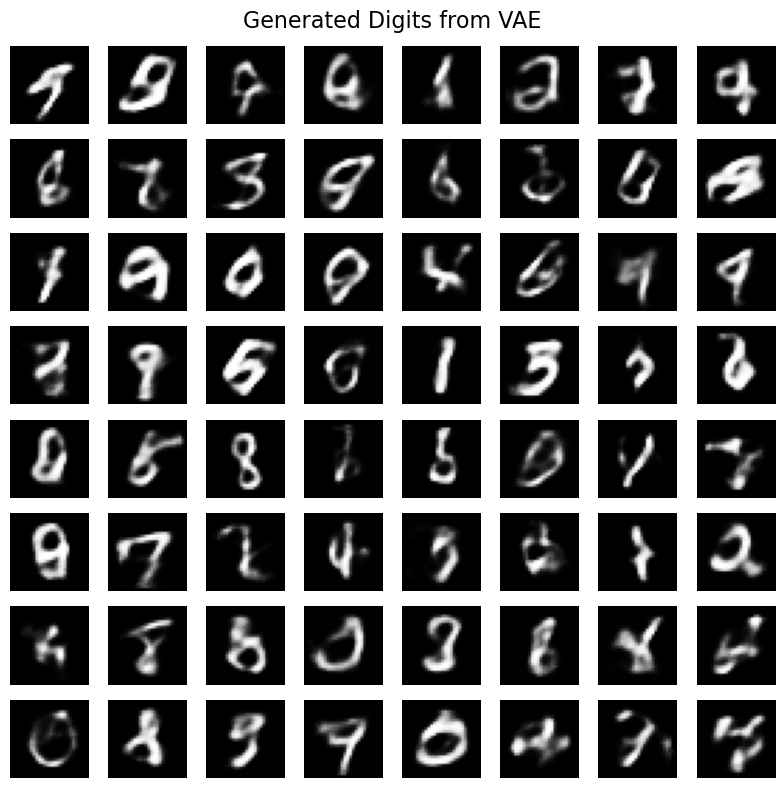

In [9]:
model.eval()
with torch.no_grad():
    # 随机采样 64 个隐变量 z (从标准正态分布 N(0,1) 中)
    z = torch.randn(64, 20).to(device)
    
    # 通过 Decoder 生成图像
    sample = model.decode(z).cpu()
    
    # 可视化生成的图像
    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(sample[i].view(28, 28), cmap='gray')
        ax.axis('off')
    
    plt.suptitle("Generated Digits from VAE", fontsize=16)
    plt.tight_layout()
    plt.show()